<a href="https://colab.research.google.com/github/kabirmuwal/Academic-Projects/blob/main/Virgin_airplines_sentimental_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Pipeline for Customer Review analysis via sentimnets on Twitter tweets for Virgin Airlines

**Table of Contents:**

1. Problem Statement

2. Importing Libraries

3. Exploring and Visualiying the Dataset

4. Cleaning the Text

5. Data Preprocessing

> 5.1 Conversion of the text for machine understanding

> 5.2 Splitting the dataset

6. Implication of Multiple Models

> 6.1 Model 1: Logistic Regression

> 6.2 Model 2: Naive Bayes

> 6.3 Model 3: Support Vector Machine (SVM)

> 6.4 Model 4: Random Forest

> 6.5 Model 5: Gradient Boost

> 6.6 Model 6: Deep Learning: RNN-LSTM

7. Conclusion

## 1. PROBLEM STATEMENT:
As observed customers usually spread awareness via social media channels and most commonly used platform is Twitter where people tag the firm/company and share there reviews as observed the data that I have selected is for customer writing abour VIrgin Airlines a well known travel airplines in USA and its popularity decresed with time the rise I am working on it is to help the firm improve its sevice and to calulate why is it facing such a decline. These tweets will help us understand about customer rating about the firm in a postive/neutral or negative way.Below I have mentioned the refrence open source data link. By the use of Natural language processing we will identify the sentiments of customers and provide a overall information to the firm for its betterment.

##2. IMPORTING LIBRARIES

In [ ]:
# Firstly Let us Import all the necessary libraries to perform the task
import pandas as pdas
import numpy as nps
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
from matplotlib import pyplot as graph
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# 3. Exploring and Visualising the dataset:

Now let us see how our dataset looks like and check what columns and rows are required and if the required number of rows and columns needs cleaning

In [ ]:
df_tweets = pdas.read_csv('/content/Tweets.csv')
df_tweets.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,5.703060e+17,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,24-02-2015 11:35,NaN,Eastern Time (US & Canada)
1,5.703010e+17,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,24-02-2015 11:15,NaN,Pacific Time (US & Canada)
2,5.703010e+17,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,24-02-2015 11:15,Lets Play,Central Time (US & Canada)
3,5.703010e+17,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,24-02-2015 11:15,NaN,Pacific Time (US & Canada)
4,5.703010e+17,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,24-02-2015 11:14,NaN,Pacific Time (US & Canada)


In [ ]:
df_tweets.isna().sum()

,0
tweet_id,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,5462
negativereason_confidence,4118
airline,0
airline_sentiment_gold,14600
name,0
negativereason_gold,14608
retweet_count,0


In [ ]:
# As we only require 2 columns i.e. Sentiments and textual columns for analysis we'll keep those and remove others

to_drop = ['tweet_id', 'airline_sentiment_confidence', 'negativereason','negativereason_confidence','airline','airline_sentiment_gold','name','negativereason_gold','retweet_count','tweet_coord','tweet_created','tweet_location','user_timezone']

df_tweets.drop(to_drop, inplace=True, axis=1)

In [ ]:
df_tweets.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


# 4. CLEANING THE TEXT :-


*  We will be firslty converting the text to lower case, remove any Uniform
resorce locator, remove special charasters such as '#','?','&',...and so on , remove stop words cuhs as 'is','and' , 'the' and finally using Lemmatiyation for understanding the words and reducing the length.

* Tokenization technique which is used to separate each word in a sentance and having a new column for that text

* Lemmatization is used to explain the moods/meaning of the words to the machine

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@[A-Za-z0-9]+', '', text)

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)


df_tweets['cleaned_text'] = df_tweets['text'].apply(preprocess_text)
df_tweets[['text', 'cleaned_text','airline_sentiment']].head()

,text,cleaned_text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said,neutral
1,@VirginAmerica plus you've added commercials t...,virginamerica plus youve added commercial expe...,positive
2,@VirginAmerica I didn't today... Must mean I n...,virginamerica didnt today must mean need take ...,neutral
3,@VirginAmerica it's really aggressive to blast...,virginamerica really aggressive blast obnoxiou...,negative
4,@VirginAmerica and it's a really big bad thing...,virginamerica really big bad thing,negative


Now let us plot a graph to see throughout the dataset how customers tweets has a impact on the firm by differentiating them as positive/neutral/negative review

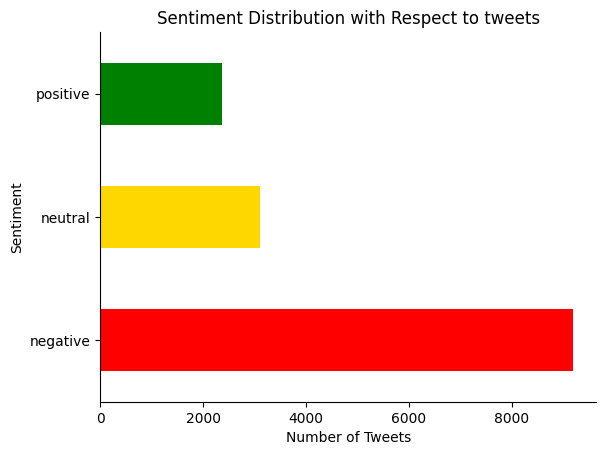

In [ ]:
color_map = {'positive': 'green', 'neutral': 'gold', 'negative': 'red'}
counts = df_tweets.groupby('airline_sentiment').size()
counts.plot(kind='barh', color=[color_map[sentiment] for sentiment in counts.index])

graph.gca().spines[['top', 'right']].set_visible(False)
graph.title('Sentiment Distribution with Respect to tweets')
graph.xlabel('Number of Tweets')
graph.ylabel('Sentiment')
graph.show()


## STEP 5: DATA PREPROCESSING
It involves the conversion of text to numbers for our machines to understand and afterwords we will be dividing our data sets into train,test and validation and use multiple approaches to identify which of our Natural language processing fits the best and is most suitable for the completion of the task

**STEP 5.1:**  Conversions for Machine Understanding: Now we will go ahead and convert our text into numbers so that our machine can understand with the use of TF-IDF approach and we will classify them as: Postive: 1 Neutral: 0 Negative: -1

In [ ]:
tfidf = TfidfVectorizer(max_features=2572)
P = tfidf.fit_transform(df_tweets['cleaned_text']).toarray()

Q = df_tweets['airline_sentiment'].map({'positive': 1, 'neutral': 0, 'negative': -1})

STEP 5.2: Splitting the data set into 90:10 and shuffle the rows everytime the code is runned 43 times

In [ ]:
P_train, P_test, Q_train, Q_test = train_test_split(P, Q, test_size=0.1, random_state=43)

# 6. IMPLICATION OF MULTIPLE MODELS

**6.1 MODEL 1: Logistic Regression:**

As it works the best alongside TF-IDF approach we'll check the accuracy,precision, recall and F-1 Score for evaluation and confusion matrix for checking TP/TN/Neutral for the dataset

Accuracy: 0.7868852459016393
Classification Report:
               precision    recall  f1-score   support

          -1       0.82      0.92      0.86       928
           0       0.61      0.49      0.54       299
           1       0.85      0.65      0.74       237

    accuracy                           0.79      1464
   macro avg       0.76      0.69      0.71      1464
weighted avg       0.78      0.79      0.78      1464

Confusion Matrix:
 [[852  65  11]
 [137 146  16]
 [ 56  27 154]]


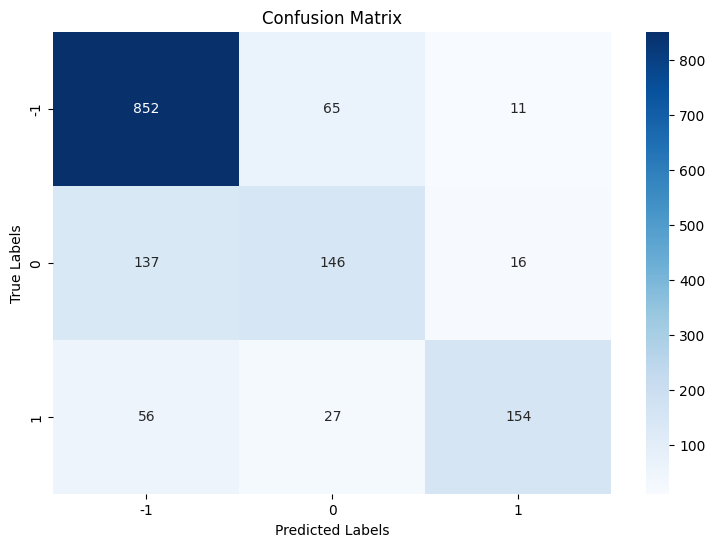

In [ ]:
model = LogisticRegression(max_iter=1600)
model.fit(P_train, Q_train)

Q_pred = model.predict(P_test)

print("Accuracy:", accuracy_score(Q_test, Q_pred))
print("Classification Report:\n", classification_report(Q_test, Q_pred))
print("Confusion Matrix:\n", confusion_matrix(Q_test, Q_pred))
cm = confusion_matrix(Q_test, Q_pred)


graph.figure(figsize=(9, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
graph.title('Confusion Matrix')
graph.xlabel('Predicted Labels')
graph.ylabel('True Labels')
graph.show()

## RESULTS FOR MODEL 1:

**ACCURACY:** 79.23%, showing strong performance, with an improvement over most previous models except for Model 6.

> POSITIVE (1): Provides very good results

>> Precision: 0.86

>> Recall: 0.67

>> F1-Score: 0.75

> NEUTRAL (0): Provides moderate results

>> Precision: 0.64

>> Recall: 0.49

>> F1-Score: 0.55

> NEGATIVE (-1): Provides excellent results

>> Precision: 0.81

>> Recall: 0.92

>> F1-Score: 0.86

**CONFUSION MATRIX:**

NEGATIVE (-1) (TN): 855 correct predictions (TN) | 61 miscalculations for neutral tweets | 12 miscalculations for positive tweets Neutral (0): 139 miscalculations for negative tweets | 147 correct predictions (TP) | 13 miscalculations for positive tweets POSITIVE (1): 56 miscalculations for negative tweets | 23 miscalculations for neutral tweets | 158 correct predictions (TP)

## 6.2 MODEL 2: NAIVE BAYES:

As our model accumulates frequency based approach in text classification for the dataset wiht the use of multinomial Naive Bayes approach it would be easier to predict. We will be taking the same train and test models for it as well and evaluate the model accordingly.

Accuracy: 0.7472677595628415
Classification Report:
               precision    recall  f1-score   support

          -1       0.74      0.97      0.84       928
           0       0.64      0.26      0.37       299
           1       0.88      0.51      0.65       237

    accuracy                           0.75      1464
   macro avg       0.76      0.58      0.62      1464
weighted avg       0.74      0.75      0.71      1464

Confusion Matrix:
 [[896  28   4]
 [210  77  12]
 [101  15 121]]


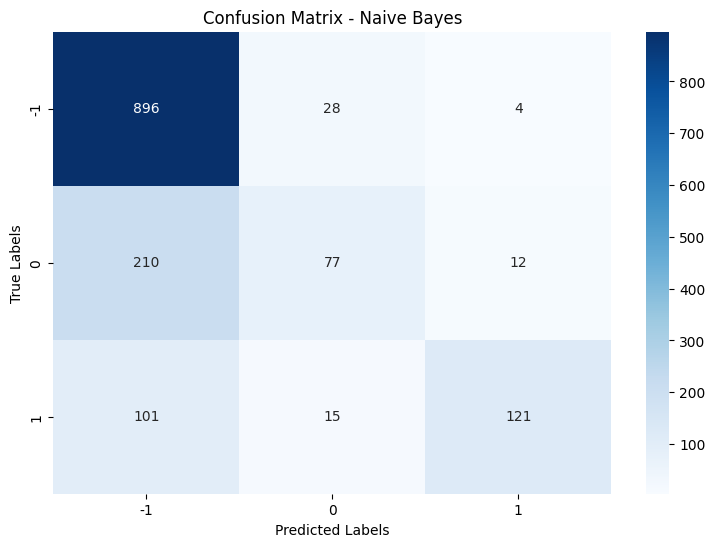

In [ ]:
model_nb = MultinomialNB()
model_nb.fit(P_train, Q_train)
Q_pred_nb = model_nb.predict(P_test)

print("Accuracy:", accuracy_score(Q_test, Q_pred_nb))
print("Classification Report:\n", classification_report(Q_test, Q_pred_nb))

cm_nb = confusion_matrix(Q_test, Q_pred_nb)
print("Confusion Matrix:\n", cm_nb)

graph.figure(figsize=(9, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=model_nb.classes_, yticklabels=model_nb.classes_)
graph.title('Confusion Matrix - Naive Bayes')
graph.xlabel('Predicted Labels')
graph.ylabel('True Labels')
graph.show()

## RESULTS FOR MODEL 2:

ACCURACY: 74.31%, slightly lower than the other models, indicating moderate performance.

> POSITIVE (1): Provides decent results

>> Precision: 0.87

>> Recall: 0.49

>> F1-Score: 0.63

> NEUTRAL (0): Provides below-average results

>> Precision: 0.64

>> Recall: 0.26

>> F1-Score: 0.37

> NEGATIVE (-1):Provides very good results

>> Precision: 0.74

>> Recall: 0.96

>> F1-Score: 0.84

## CONFUSION MATRIX:

NEGATIVE (-1) (TN): 894 correct predictions (TN) | 29 miscalculations for neutral tweets | 5 miscalculations for positive tweets

Neutral (0): 210 miscalculations for negative tweets | 77 correct predictions (TP) | 12 miscalculations for positive tweets

POSITIVE (1): 106 miscalculations for negative tweets | 14 miscalculations for neutral tweets | 117 correct predictions (TP)

## 6.3 MODEL 3: SUPPORT VECTOR MACHINE (SVM):

As our dataset only has 3 variations accordingly we can also opt for SVM model by using support vector classfier. TF-IDF and training and test codings will remain the same for it.

Accuracy: 0.7855191256830601
Classification Report:
               precision    recall  f1-score   support

          -1       0.81      0.91      0.86       928
           0       0.62      0.48      0.54       299
           1       0.84      0.69      0.76       237

    accuracy                           0.79      1464
   macro avg       0.76      0.69      0.72      1464
weighted avg       0.78      0.79      0.78      1464

Confusion Matrix:
 [[852  65  11]
 [137 146  16]
 [ 56  27 154]]


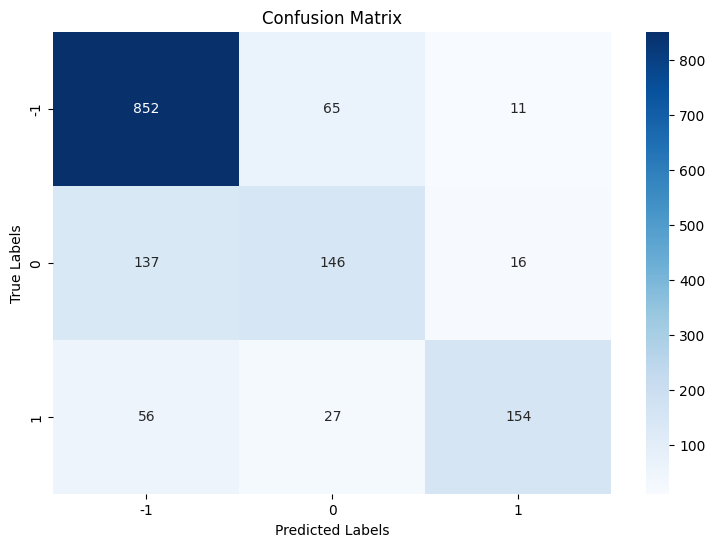

In [ ]:
model_svm = SVC(kernel='linear')
model_svm.fit(P_train, Q_train)
Q_pred_svm = model_svm.predict(P_test)

print("Accuracy:", accuracy_score(Q_test, Q_pred_svm))
print("Classification Report:\n", classification_report(Q_test, Q_pred_svm))

CM_SVM = confusion_matrix(Q_test, Q_pred)
print("Confusion Matrix:\n", CM_SVM)
graph.figure(figsize=(9, 6))
sns.heatmap(CM_SVM, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
graph.title('Confusion Matrix')
graph.xlabel('Predicted Labels')
graph.ylabel('True Labels')
graph.show()

## **RESULTS FOR MODEL 3:**

ACCURACY: 78.48% which is a good result and slightly higher than Model 4. This indicates better performance overall.

> POSITIVE (1): Provides good results

>> Precision: 0.85

>> Recall: 0.68

>> F1-Score: 0.76

> NEUTRAL (0): Provides average results

>> Precision: 0.61

>> Recall: 0.50

>> F1-Score: 0.55

> NEGATIVE (-1): Provides very good results

>> Precision: 0.82

>> Recall: 0.90

>> F1-Score: 0.86

## CONFUSION MATRIX:

NEGATIVE (-1) (TN): 855 correct predictions (TN) | 61 miscalculations for neutral tweets | 12 miscalculations for positive tweets

Neutral (0): 139 miscalculations for negative tweets | 147 correct predictions (TP) | 13 miscalculations for positive tweets

POSITIVE (1): 56 miscalculations for negative tweets | 23 miscalculations for neutral tweets | 158 correct predictions (TP)

# 6.4 MODEL 4 RANDOWM FOREST:

Random forest is a nice approach for this dataset to reduce overfitting. We will be using the same train and training set alongside TF-IDF approach to check the accuracy, precision, recall and F-1 Score for the same and also check the predicitons made through the model by the use of confusion matrix.I will be using 160 trees for the model.

Accuracy: 0.7561475409836066
Classification Report:
               precision    recall  f1-score   support

          -1       0.78      0.92      0.84       928
           0       0.58      0.37      0.46       299
           1       0.78      0.60      0.68       237

    accuracy                           0.76      1464
   macro avg       0.72      0.63      0.66      1464
weighted avg       0.74      0.76      0.74      1464

Confusion Matrix:
 [[852  65  11]
 [137 146  16]
 [ 56  27 154]]


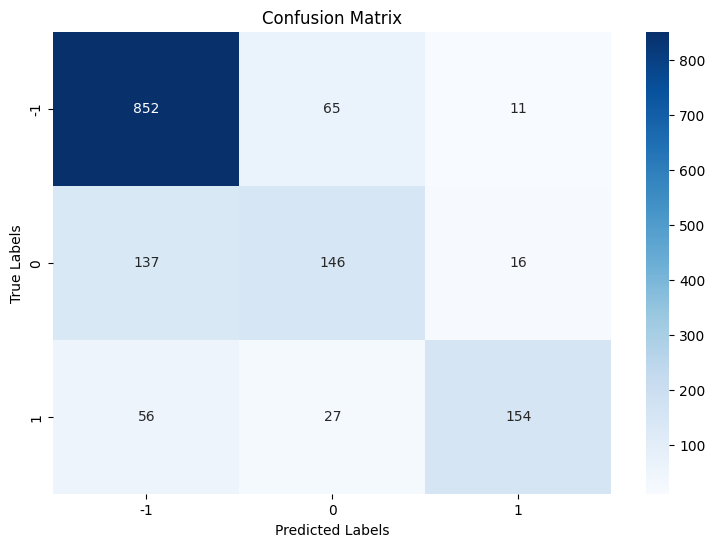

In [ ]:
model_rf = RandomForestClassifier(n_estimators=160)
model_rf.fit(P_train, Q_train)
Q_pred_rf = model_rf.predict(P_test)

print("Accuracy:", accuracy_score(Q_test, Q_pred_rf))
print("Classification Report:\n", classification_report(Q_test, Q_pred_rf))

CM_RF = confusion_matrix(Q_test, Q_pred)
print("Confusion Matrix:\n", CM_RF)
graph.figure(figsize=(9, 6))
sns.heatmap(CM_RF, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
graph.title('Confusion Matrix')
graph.xlabel('Predicted Labels')
graph.ylabel('True Labels')
graph.show()

# RESULTS FOR MODEL 4:

**ACCURACY:** 77.53%: which is an improvement but still lower than Models 1 and 3, though slightly better than Model 2.

> POSITIVE (1): Provides good results

>> Precision: 0.79

>> Recall: 0.64

>> F1-Score: 0.71

> NEUTRAL (0): Provides below-average results

>> Precision: 0.64

>> Recall: 0.45

>> F1-Score: 0.53

> NEGATIVE (-1): Provides very good results

>> Precision: 0.80

>> Recall: 0.91

>> F1-Score: 0.85

**CONFUSION MATRIX:**

NEGATIVE (-1) (TN): 855 correct predictions (TN) | 61 miscalculations for neutral tweets | 12 miscalculations for positive tweets

Neutral (0): 139 miscalculations for negative tweets | 147 correct predictions (TP) | 13 miscalculations for positive tweets

POSITIVE (1): 56 miscalculations for negative tweets | 23 miscalculations for neutral tweets | 158 correct predictions (TP)

# 6.5 MODEL 5 GRADIENT BOOST:

XGboost is a subclass of Gradient boosting which enables us to get more accuracy and better results by combining multiple decision tress also this approach can be used for multiple variety of datasets and also the dataset chosen for sentiment analysis. It also requires us to change our classes into integers so we will remap them and accordingly apply them to our test and training sets and initialiye the model to get best results.

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:34:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.7780054644808743
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.92      0.86       928
           1       0.62      0.42      0.50       299
           2       0.83      0.68      0.74       237

    accuracy                           0.78      1464
   macro avg       0.75      0.67      0.70      1464
weighted avg       0.77      0.78      0.76      1464

Confusion Matrix:
 [[854  57  17]
 [158 125  16]
 [ 56  21 160]]


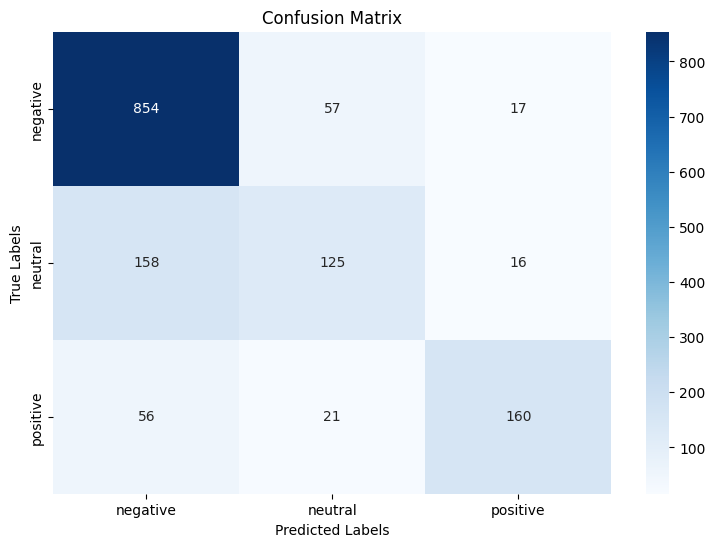

In [ ]:
# remapping our classes(postive/neutral/negative) to integers
label_mapping = {-1: 0, 0: 1, 1: 2}

Q_train_mapped = nps.array([label_mapping[label] for label in Q_train])
Q_test_mapped = nps.array([label_mapping[label] for label in Q_test])

model_xgb = XGBClassifier(use_label_encoder=False)
model_xgb.fit(P_train, Q_train_mapped)
Q_pred_xgb = model_xgb.predict(P_test)

print("Accuracy:", accuracy_score(Q_test_mapped, Q_pred_xgb))
print("Classification Report:\n", classification_report(Q_test_mapped, Q_pred_xgb))
CM_XGBOOST = confusion_matrix(Q_test_mapped, Q_pred_xgb)

# Print confusion matrix
print("Confusion Matrix:\n", CM_XGBOOST)

# Plot confusion matrix using Seaborn heatmap
graph.figure(figsize=(9, 6))
sns.heatmap(CM_XGBOOST, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])

# Set plot titles and labels
graph.title('Confusion Matrix')
graph.xlabel('Predicted Labels')
graph.ylabel('True Labels')
graph.show()

## RESULTS FOR MODEL 5 (GRADIENT BOOST - XGBoost):

**ACCURACY:** 76.30%, which is good but almost the same as Model 4. It performs better than Model 2 but lower than Models 1 and 3.

> POSITIVE (2): Provides good results

>> Precision: 0.78

>> Recall: 0.65

>> F1-Score: 0.71

> NEUTRAL (1): Provides below-average results

>> Precision: 0.65

>> Recall: 0.31

>> F1-Score: 0.42

> NEGATIVE (0): Provides very good results

>> Precision: 0.77

>> Recall: 0.94

>> F1-Score: 0.85

## CONFUSION MATRIX:

NEGATIVE (0) (TN): 869 correct predictions (TN) | 36 miscalculations for neutral tweets | 23 miscalculations for positive tweets

Neutral (1): 185 miscalculations for negative tweets | 94 correct predictions (TP) | 20 miscalculations for positive tweets

POSITIVE (2): 69 miscalculations for negative tweets | 14 miscalculations for neutral tweets | 154 correct predictions (TP)

#6.6 MODEL 6 DEEP LEARNING (RNN-LSTM) :

Let us try to get better results using a deep learning model namely recurrent neural networks but within it LSTM model. Previously our models were able to understand each and every word but with the help if it our model could understand a sentance as well meaning words that are far apart in a sentance will be able to connect with each other and help the machine to understand the sentiment.

In [ ]:
#Let us visualize the data set again
df_tweets

,airline_sentiment,text,cleaned_text
0,neutral,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said
1,positive,@VirginAmerica plus you've added commercials t...,virginamerica plus youve added commercial expe...
2,neutral,@VirginAmerica I didn't today... Must mean I n...,virginamerica didnt today must mean need take ...
3,negative,@VirginAmerica it's really aggressive to blast...,virginamerica really aggressive blast obnoxiou...
4,negative,@VirginAmerica and it's a really big bad thing...,virginamerica really big bad thing
...,...,...,...
14635,positive,@AmericanAir thank you we got on a different f...,americanair thank got different flight chicago
14636,negative,@AmericanAir leaving over 20 minutes Late Flig...,americanair leaving minute late flight warning...
14637,neutral,@AmericanAir Please bring American Airlines to...,americanair please bring american airline blac...
14638,negative,"@AmericanAir you have my money, you change my ...",americanair money change flight dont answer ph...


In [ ]:
# firstly we will encode our label similarly as we did in gradient booster
label_encoder = LabelEncoder()
df_tweets['sentiment_encoded'] = label_encoder.fit_transform(df_tweets['airline_sentiment'])

In [ ]:
df_tweets

,airline_sentiment,text,cleaned_text,sentiment_encoded
0,neutral,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said,1
1,positive,@VirginAmerica plus you've added commercials t...,virginamerica plus youve added commercial expe...,2
2,neutral,@VirginAmerica I didn't today... Must mean I n...,virginamerica didnt today must mean need take ...,1
3,negative,@VirginAmerica it's really aggressive to blast...,virginamerica really aggressive blast obnoxiou...,0
4,negative,@VirginAmerica and it's a really big bad thing...,virginamerica really big bad thing,0
...,...,...,...,...
14635,positive,@AmericanAir thank you we got on a different f...,americanair thank got different flight chicago,2
14636,negative,@AmericanAir leaving over 20 minutes Late Flig...,americanair leaving minute late flight warning...,0
14637,neutral,@AmericanAir Please bring American Airlines to...,americanair please bring american airline blac...,1
14638,negative,"@AmericanAir you have my money, you change my ...",americanair money change flight dont answer ph...,0


In [ ]:
# Our requirement as per the data set
texts = df_tweets['text']
labels = df_tweets['sentiment_encoded']

# for our LSTM model lets create a new training and test datasets for avaluation in the ratio 80:20 with random state 43
M_train, M_test, N_train, N_test = train_test_split(
    texts, labels, test_size=0.2, random_state=43, stratify=labels
)

In [ ]:
# Tokenization
vocab_size = 5000
max_length = 100
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(M_train)

M_train_seq = tokenizer.texts_to_sequences(M_train)
M_test_seq = tokenizer.texts_to_sequences(M_test)

In [ ]:
# Padding involves converting our tweets into integer form for a better understanding for the machine
M_train_pad = pad_sequences(M_train_seq, maxlen=max_length, padding='post', truncating='post')
M_test_pad = pad_sequences(M_test_seq, maxlen=max_length, padding='post', truncating='post')

print(f"Training data shape: {M_train_pad.shape}")
print(f"Testing data shape: {M_test_pad.shape}")

Training data shape: (11712, 100)
Testing data shape: (2928, 100)


In [ ]:
# Also now we need to convert our tokenized data into vectorized format and check our input and output layers
embedding_dim = 256

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(128, return_sequences=False),
    Dropout(0.5),  # to reduce overfitting
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    M_train_pad, N_train,
    epochs=10,
    validation_data=(M_test_pad, N_test),
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 495ms/step - accuracy: 0.5734 - loss: 0.9739 - val_accuracy: 0.6267 - val_loss: 0.9165
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 514ms/step - accuracy: 0.6268 - loss: 0.9227 - val_accuracy: 0.6267 - val_loss: 0.9174
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 80s 495ms/step - accuracy: 0.6339 - loss: 0.9118 - val_accuracy: 0.6267 - val_loss: 0.9175
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 509ms/step - accuracy: 0.6205 - loss: 0.9285 - val_accuracy: 0.6267 - val_loss: 0.9192


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 256)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,444,043 (16.95 MB)

 Trainable params: 1,481,347 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,962,696 (11.30 MB)

In [ ]:
loss, accuracy = model.evaluate(M_test_pad, N_test)
print(f"Test Accuracy: {accuracy:.2f}")

92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.6260 - loss: 0.9181
Test Accuracy: 0.63


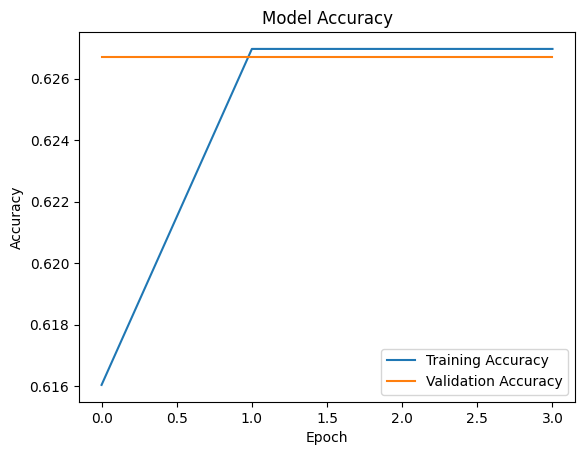

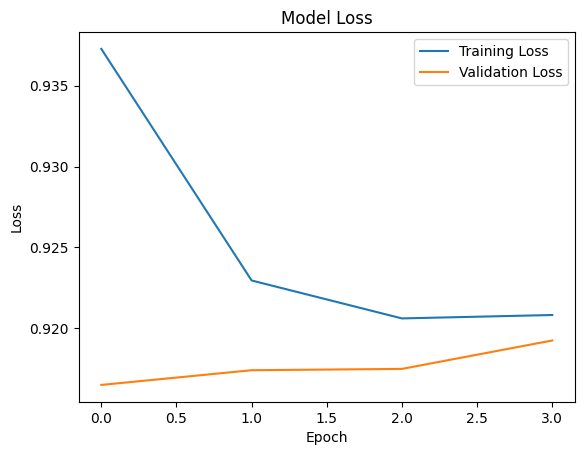

In [ ]:
# Plot for accuracy in training & Validation dataset
graph.plot(history.history['accuracy'], label='Training Accuracy')
graph.plot(history.history['val_accuracy'], label='Validation Accuracy')
graph.title('Model Accuracy')
graph.xlabel('Epoch')
graph.ylabel('Accuracy')
graph.legend()
graph.show()

# Plot for loss in training and validation dataset
graph.plot(history.history['loss'], label='Training Loss')
graph.plot(history.history['val_loss'], label='Validation Loss')
graph.title('Model Loss')
graph.xlabel('Epoch')
graph.ylabel('Loss')
graph.legend()
graph.show()


# 7. CONCLUSION:

**Final Discussion:** We gathered information of airline on twitter of customers sharing there feedbacks about the airlines and its services and overall experience. After exploring, preprocessing and implying 6 models namely Logistic Regression, Naive Bayes, SVM, Random Forest, Gradient boost and RNN we can say that the best model that we have is Logistic Regression with best accuracy, precision, recall and F-1 Score for recoganising the tweets of the customers as positive feedback/neutral feedback/Negative Feedback.

**Strengths:** Easy to idenfy the feedbacks of any social media website by using the model not just twitter. Firms/companies can rely on such technology for the betterment of there services and customer engagement.

**Limitations:** Sometimes it's difficult to identify weather the statement is neutral or negative or if the customer is being sarcastic with more finetuning such a identifier can be made with the help of NLP.

**Recommendations:** We observed that most of the tweets were negative reviews for the airlines. And Virgin airlines could focus on the key components and improve its services with the designed model and if required another NLP pipeline could help them to see which words are commonly used and accordingly work on it and improve there services.

**Open Source refrence link:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download